In [ ]:
#-------ACCESS TO GOOGLE DRIVE IN COLAB-------
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/CT/Proj.zip -d ./dane

Archive:  /content/drive/MyDrive/CT/Proj.zip
   creating: ./dane/Proj/
  inflating: ./dane/Proj/img_00000.tif  
  inflating: ./dane/Proj/img_00001.tif  
  inflating: ./dane/Proj/img_00002.tif  
  inflating: ./dane/Proj/img_00003.tif  
  inflating: ./dane/Proj/img_00004.tif  
  inflating: ./dane/Proj/img_00005.tif  
  inflating: ./dane/Proj/img_00006.tif  
  inflating: ./dane/Proj/img_00007.tif  
  inflating: ./dane/Proj/img_00008.tif  
  inflating: ./dane/Proj/img_00009.tif  
  inflating: ./dane/Proj/img_00010.tif  
  inflating: ./dane/Proj/img_00011.tif  
  inflating: ./dane/Proj/img_00012.tif  
  inflating: ./dane/Proj/img_00013.tif  
  inflating: ./dane/Proj/img_00014.tif  
  inflating: ./dane/Proj/img_00015.tif  
  inflating: ./dane/Proj/img_00016.tif  
  inflating: ./dane/Proj/img_00017.tif  
  inflating: ./dane/Proj/img_00018.tif  
  inflating: ./dane/Proj/img_00019.tif  
  inflating: ./dane/Proj/img_00020.tif  
  inflating: ./dane/Proj/img_00021.tif  
  inflating: ./dane/Proj/im

In [ ]:
import os
import re
import torch
import numpy as np
import tifffile
from math import ceil, sqrt
from tqdm import tqdm
import time
from math import ceil, sqrt
from scipy.ndimage import map_coordinates
import matplotlib.pyplot as plt

In [ ]:

# -----------------------
# Parameters 
# -----------------------
data_dir = "./dane/Proj"
proj_step = 6         # every nth projection (for testing, we can use fewer projections)
row_step = 1           # all rows (for testing, we can use fewer rows)
block_size = 28       # block size for FBP 
batch_rows = 1         # rows batch GPU
batch_angles = 1     # projections batch GPU
use_circle = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# -----------------------
# Natural sorting of files
# -----------------------
def natural_sort_key(s):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', s)]

all_files = sorted([f for f in os.listdir(data_dir) if f.lower().endswith((".tif", ".tiff"))],
                   key=natural_sort_key)
selected_files = all_files[::proj_step]
n_angles = len(selected_files)

# -----------------------
# Dimensions of the sample image
# -----------------------

sample = tifffile.imread(os.path.join(data_dir, selected_files[0]))
if sample.ndim == 3:
    sample = sample[..., 0]
H, W = sample.shape


Generowanie sinogramu...


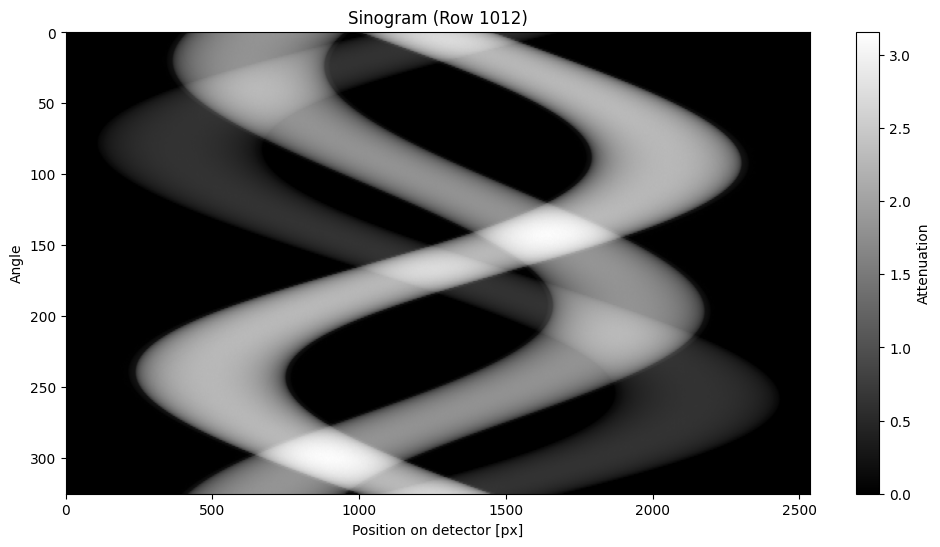

1012


In [ ]:
# ----------------------------------------------------------------------------------------------------------------------------
# Creating the sinogram by extracting the middle row from each log-transformed projection (Radon transform)
# ----------------------------------------------------------------------------------------------------------------------------

sinogram_list = []
row_to_extract = H // 2

print("Generowanie sinogramu...")

for f in selected_files:
    # 1. Reaning the image (if it's RGB, we take only one channel)
    img_raw = tifffile.imread(os.path.join(data_dir, f)).astype(np.float32)
    if img_raw.ndim == 3:
        img_raw = img_raw[..., 0]

    # 2. Log-transform the image (Lambert-Beer's law)
    I0 = np.percentile(img_raw, 99.5)
    img_log = np.log(np.maximum(I0, 1e-3) / np.maximum(img_raw, 1e-3))
    img_log = np.maximum(img_log, 0)

    # 3. Row extraction
    line = img_log[row_to_extract, :]
    sinogram_list.append(line)

# 4. Convert list to array and visualize
sinogram = np.array(sinogram_list)
plt.rc('text', usetex=False)
plt.figure(figsize=(12, 6))
plt.imshow(sinogram, cmap='gray', aspect='auto')
plt.title("Sinogram (Row 1012)")
plt.xlabel("Position on detector [px]")
plt.ylabel("Angle")
plt.colorbar(label='Attenuation')
plt.savefig("sinogram.png")
plt.show()
print(row_to_extract)

In [ ]:
# -----------------------
# Preparing the Ramlak filter
# -----------------------
freqs = np.fft.fftfreq(W)
ramlak = np.abs(freqs)
filter_fft = ramlak
print(n_angles)
Y_full, X_full = np.meshgrid(
    np.arange(H) - W//2,
    np.arange(W) - W//2,
    indexing='ij'
)


326


In [ ]:
#preparing the container for reconstruction
recon_acc = np.zeros((H, W), dtype=np.float32)
# -----------------------
# Reconstruction
# -----------------------
start_total = time.time()

for idx, f in enumerate(selected_files):
    slice_start = time.time()
    img_raw = tifffile.imread(os.path.join(data_dir, f)).astype(np.float32)
    I0 = np.percentile(img_raw, 99.5)
    img_log = np.log(np.maximum(I0, 1e-3) / np.maximum(img_raw, 1e-3))
    img_log = np.maximum(img_log, 0)
    img = img_log
    # FFT and filtering in frequency domain
    proj_fft = np.fft.fft(img, axis=1)
    filtered = np.real(np.fft.ifft(proj_fft * filter_fft, axis=1))

    theta = 2 * np.pi * idx / len(selected_files)
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)

    # reconstructing the image by backprojection (interpolation)
    for i_start in range(0, H, block_size):
        i_end = min(i_start + block_size, H)
        for j_start in range(0, W, block_size):
            j_end = min(j_start + block_size, W)

            Xb = X_full[i_start:i_end, j_start:j_end]
            Yb = Y_full[i_start:i_end, j_start:j_end]

            # position on the detector for each pixel in the block (center + 0.5 px)
            det_x = Xb * sin_t + Yb * cos_t + W/2

            # 1) calculate row indices corresponding to Yb (clip if Yb is out of bounds)
            row_idx = (Yb + H//2).astype(np.float32)   # float coords for map_coordinates
            col_idx = det_x.astype(np.float32)         # x positions in columns

            # 2) creating coordinates (ndim, npoints) = (2, N)
            coords = np.vstack((row_idx.ravel(), col_idx.ravel()))

            # 3) sampling map_coordinates (order=1 -> bilinear)
            sampled = map_coordinates(filtered, coords, order=1, mode='nearest')

            # 4) reshape back to block and add to accumulator
            block = sampled.reshape(det_x.shape)
            recon_acc[i_start:i_end, j_start:j_end] += block

    slice_end = time.time()
    print(f"Slice {idx+1}/{len(selected_files)} w {slice_end - slice_start:.2f}s")

# normalize by the number of projections
recon_acc /= len(selected_files)

end_total = time.time()
print("Całkowity czas:", end_total - start_total)

Slice 1/326 w 2.21s
Slice 2/326 w 2.07s
Slice 3/326 w 1.43s
Slice 4/326 w 1.32s
Slice 5/326 w 1.36s
Slice 6/326 w 1.28s
Slice 7/326 w 1.39s
Slice 8/326 w 1.28s
Slice 9/326 w 1.29s
Slice 10/326 w 1.79s
Slice 11/326 w 2.04s
Slice 12/326 w 1.51s
Slice 13/326 w 1.31s
Slice 14/326 w 1.26s
Slice 15/326 w 1.33s
Slice 16/326 w 1.34s
Slice 17/326 w 1.34s
Slice 18/326 w 1.32s
Slice 19/326 w 1.54s
Slice 20/326 w 2.01s
Slice 21/326 w 1.92s
Slice 22/326 w 1.32s
Slice 23/326 w 1.39s
Slice 24/326 w 1.31s
Slice 25/326 w 1.34s
Slice 26/326 w 1.33s
Slice 27/326 w 1.37s
Slice 28/326 w 1.38s
Slice 29/326 w 2.17s
Slice 30/326 w 2.08s
Slice 31/326 w 1.42s
Slice 32/326 w 1.35s
Slice 33/326 w 1.36s
Slice 34/326 w 1.32s
Slice 35/326 w 1.37s
Slice 36/326 w 1.33s
Slice 37/326 w 1.42s
Slice 38/326 w 1.83s
Slice 39/326 w 2.22s
Slice 40/326 w 1.44s
Slice 41/326 w 1.39s
Slice 42/326 w 1.39s
Slice 43/326 w 1.44s
Slice 44/326 w 1.35s
Slice 45/326 w 1.40s
Slice 46/326 w 1.38s
Slice 47/326 w 1.88s
Slice 48/326 w 2.07s
S

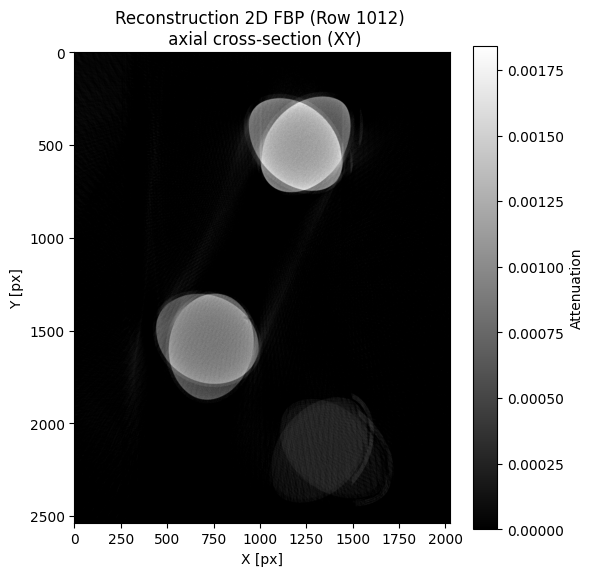

In [ ]:
# 1. Rotating the matrix by 90 degrees (k=1 for 90 degrees counterclockwise)
# This makes the circle pattern change from horizontal to vertical
data_fixed = np.rot90(np.maximum(recon_acc, 0), k=1)

# 2. Creating the figure. Since the image is now tall, figsize should be something like (6, 10)
plt.figure(figsize=(6, 6))

# 3. KEY: aspect='equal' ensures that circles remain circles
plt.imshow(data_fixed, cmap='gray', aspect='equal')

plt.title("Reconstruction 2D FBP (Row 1012) \n axial cross-section (XY)")
plt.xlabel("X [px]")
plt.ylabel("Y [px]")

# Colorbar added to the figure
plt.colorbar(label='Attenuation')

plt.tight_layout()
plt.savefig("FBP_fixed_v3.png", bbox_inches='tight')
plt.show()

     CENTER OF ROTATION – ANALIZA
→ wykryte przesunięcie osi = 0 px
(dodatnie = obraz 180° trzeba przesunąć w prawo)


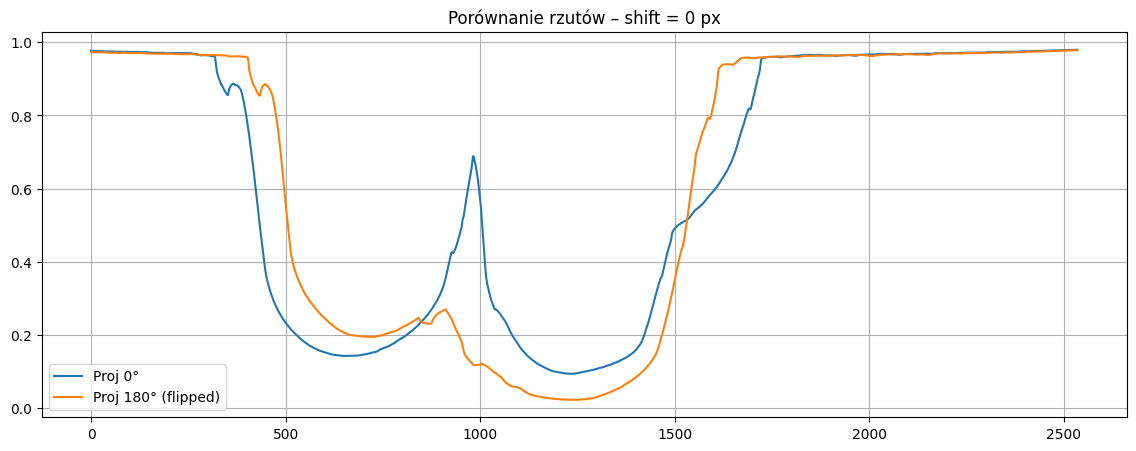

In [ ]:
#--------------------------------------------------------------------------------------------------------------------------------------------------------------
# Additional analysis: Center of rotation – cross-correlation between 0° and 180° projections
#--------------------------------------------------------------------------------------------------------------------------------------------------------------

from scipy.signal import correlate

# ---- Reading two projections with 180° difference ----

idx0 = 0
idx180 = len(selected_files) // 2

path0 = os.path.join(data_dir, selected_files[idx0])
path180 = os.path.join(data_dir, selected_files[idx180])

proj0 = tifffile.imread(path0).astype(np.float32)
proj180 = tifffile.imread(path180).astype(np.float32)

# ---- Normalization ----
proj0 = (proj0 - proj0.min()) / (proj0.max() - proj0.min())
proj180 = (proj180 - proj180.min()) / (proj180.max() - proj180.min())

# ---- Second projection (flipped) ----
proj180_flipped = np.flip(proj180, axis=1)

# ---- Averaging in the vertical direction -> 1D lines ----
line0 = proj0.mean(axis=0)
line180 = proj180_flipped.mean(axis=0)

# ---- CROSS-correlation ----
corr = correlate(line0, line180, mode='full')
shift = corr.argmax() - (len(line0) - 1)

print("======================================")
print("     CENTER OF ROTATION – ANALIZA")
print("======================================")
print(f"→ wykryte przesunięcie osi = {shift} px")
print(f"(dodatnie = obraz 180° trzeba przesunąć w prawo)")
print("======================================")

# ---- WIZUALIZACJA ----
plt.figure(figsize=(14,5))
plt.plot(line0, label="Proj 0°")
plt.plot(line180, label="Proj 180° (flipped)")
plt.title(f"Porównanie rzutów – shift = {shift} px")
plt.legend()
plt.grid()
plt.show()
